# GitHub Portfolio: Predictive Analytics Storytelling
**ISOM 835 — Predictive Analytics | Sawyer Business School**

---

## You've Been Hired

A company just brought you on as a data analyst. They have a business problem and a dataset. They need two things from you:

1. **A working predictive model** — Can you actually predict the outcome?
2. **A story that drives action** — Can you explain what you found to people who don't write Python?

Your deliverable is a **professional GitHub repository** containing your analysis notebook and a README that tells the story. Think of the README as the executive summary that the VP reads over coffee — and the notebook as the appendix they'll never open unless they're impressed.

---

## Choose Your Client

Pick **one** of the three business scenarios below. Each involves a real-world dataset and a classification problem. Choose the industry that interests you most — your portfolio will be more compelling when you care about the problem.

| | Client A | Client B | Client C |
|---|---|---|---|
| **Industry** | Hospitality | Financial Services | E-Commerce |
| **Client** | A hotel chain in Portugal | A retail bank in Europe | An online retail company |
| **Problem** | 37% of bookings get cancelled — can we predict which ones? | Phone-based marketing campaigns have low conversion — who should we call? | Only 15% of website visitors buy — can we identify who will convert? |
| **Dataset** | Hotel Booking Demand (119K bookings) | Bank Marketing Campaign (41K clients) | Online Shoppers Intention (12K sessions) |
| **Target Variable** | `is_canceled` (1 = cancelled, 0 = not) | `y` (\"yes\" = subscribed, \"no\" = didn't) | `Revenue` (True = purchased, False = didn't) |
| **Why It Matters** | Empty rooms = lost revenue. Overbooking = angry guests. | Every unnecessary call costs money. Every missed lead costs more. | Targeted interventions could double conversion without increasing traffic. |

---

## Step 0: Load Your Dataset

Run the starter code for the client you chose. Each cell loads the data into a DataFrame called `df` so the rest of your workflow is the same regardless of which dataset you pick.

**Only run the cell for your chosen client.**

In [3]:
# ============================================================
# CLIENT A: Hotel Booking Demand
# ============================================================
# A hotel chain in Portugal wants to predict booking cancellations.
# Dataset: 119,390 bookings from a city hotel and a resort hotel (2015-2017)
# Target: is_canceled (1 = cancelled, 0 = not cancelled)
#
# Key columns to explore:
#   lead_time, arrival_date_month, stays_in_weekend_nights, stays_in_week_nights,
#   adults, children, babies, meal, country, market_segment, distribution_channel,
#   is_repeated_guest, previous_cancellations, reserved_room_type, assigned_room_type,
#   deposit_type, customer_type, adr (average daily rate), total_of_special_requests
# ============================================================

import pandas as pd

url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-02-11/hotels.csv"
df = pd.read_csv(url)
print(f"Dataset loaded: {df.shape[0]:,} bookings, {df.shape[1]} columns")
df.head()

Dataset loaded: 119,390 bookings, 32 columns


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
# @title
# ============================================================
# CLIENT B: Bank Marketing Campaign
# ============================================================
# A European retail bank wants to predict which clients will subscribe
# to a term deposit after a phone marketing campaign.
# Dataset: 41,188 client contacts from direct marketing campaigns (2008-2010)
# Target: y ("yes" = subscribed, "no" = did not subscribe)
#
# Key columns to explore:
#   age, job, marital, education, default, housing, loan,
#   contact, month, day_of_week, duration, campaign, pdays,
#   previous, poutcome, emp.var.rate, cons.price.idx, cons.conf.idx,
#   euribor3m, nr.employed
# ============================================================

!pip install ucimlrepo -q

import pandas as pd
from ucimlrepo import fetch_ucirepo

dataset = fetch_ucirepo(id=222)  # Bank Marketing
df = pd.concat([dataset.data.features, dataset.data.targets], axis=1)
print(f"Dataset loaded: {df.shape[0]:,} clients, {df.shape[1]} columns")
df.head()

KeyboardInterrupt: 

In [ ]:
# @title
# ============================================================
# CLIENT C: Online Shoppers Purchase Intention
# ============================================================
# An e-commerce company wants to predict which website visitors
# will actually complete a purchase.
# Dataset: 12,330 user sessions over a 1-year period
# Target: Revenue (True = purchased, False = did not purchase)
#
# Key columns to explore:
#   Administrative, Administrative_Duration, Informational, Informational_Duration,
#   ProductRelated, ProductRelated_Duration, BounceRates, ExitRates, PageValues,
#   SpecialDay, Month, OperatingSystems, Browser, Region, TrafficType,
#   VisitorType, Weekend
# ============================================================

!pip install ucimlrepo -q

import pandas as pd
from ucimlrepo import fetch_ucirepo

dataset = fetch_ucirepo(id=468)  # Online Shoppers Purchasing Intention
df = pd.concat([dataset.data.features, dataset.data.targets], axis=1)
print(f"Dataset loaded: {df.shape[0]:,} sessions, {df.shape[1]} columns")
df.head()

---

## The Storytelling Arc

Every great analytics project follows a narrative. Yours should too. The sections below map to the four parts of your story:

| Story Beat | What You Do | What You Write |
|---|---|---|
| **1. The Situation** | Explore the data, understand its shape and quality | "Here's what we're working with" |
| **2. The Discovery** | Dig into patterns — who, what, when, why? | "Here's what the data reveals" |
| **3. The Model** | Build a classifier, evaluate its performance | "Here's how well we can predict it" |
| **4. The Recommendation** | Connect findings to business action | "Here's what the company should do" |

After each section of code, you'll write an interpretation in plain English. These interpretations will become the backbone of your GitHub README.

---

## Part 1: The Situation (10 points)

Your client just handed you the data. Before you do anything fancy, understand what you're working with.

**Your analysis should include:**
- Shape of the data (rows, columns)
- Data types and any quality issues (missing values, unexpected types)
- Distribution of the target variable — how imbalanced is the problem?
- Basic summary statistics of key numerical columns

**Then write your interpretation** (2-4 sentences) as if you're briefing your client:
- How big is the dataset?
- What's the base rate of the outcome? (e.g., "37% of bookings are cancelled")
- Any data quality concerns they should know about?

In [5]:
# Your analysis code here
# 1. Shape of the data
rows = df.shape[0]
cols = df.shape[1]
print(f"Total Rows: {rows}")
print(f"Total Columns: {cols}")

# 2. Data types and quality issues
print("\n--- Data Types ---")
df.info()

print("\n--- Missing Values ---")
print(df.isna().sum())

# 3. Distribution of the target variable
# IMPORTANT: Change the text inside the quotes to your actual column name!
# Check the 'Data Types' output above to find the exact spelling.
target_col = 'is_canceled'

print(f"\n--- Target Variable Distribution (Raw) for '{target_col}' ---")
print(df[target_col].value_counts())

print(f"\n--- Target Variable Distribution (Percentages) for '{target_col}' ---")
print(df[target_col].value_counts(normalize=True))

# 4. Basic summary statistics
print("\n--- Summary Statistics ---")
print(df.describe())

Total Rows: 119390
Total Columns: 32

--- Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies               

Client Briefing — The Situation:

Write your interpretation here. Imagine you're in a meeting room with the VP. No jargon.

*We are working with a comprehensive dataset of 119,390 hotel booking records across 32 distinct features. Our baseline cancellation rate is 37%, giving us a solid, moderately balanced target for our predictive model. Overall data quality is high, though we need to address significant missing data in the 'company' and 'agent' fields (missing 94% and 13% of records, respectively) and investigate a few potential outliers in room rates and party sizes before proceeding.*





---

## Part 2: The Discovery (30 points)

This is the heart of your analysis. Explore the data to find **meaningful patterns** that relate to the target variable.

**Your analysis should include:**
- At least **3 different angles** of exploration (e.g., demographics, behavior, timing, service type — whatever makes sense for your dataset)
- At least **3 visualizations** (bar charts, histograms, box plots, scatter plots, heatmaps — your choice)
- Use of `.groupby()`, `.value_counts()`, filtering, or other Pandas techniques we covered in class
- Each angle should compare the outcome groups (e.g., cancelled vs. not cancelled, purchased vs. didn't)

**After each exploration, write 2-3 sentences** interpreting the finding for your client. Don't describe the chart — tell them what it *means*.

| Good Interpretation | Bad Interpretation |
|---|---|
| *"Customers on month-to-month contracts churn at 3x the rate of those on annual contracts. Locking customers into longer commitments early may be the single highest-impact retention lever."* | *"The bar chart shows that month-to-month is higher than annual."* |

Use as many code and text cells as you need below. Add more cells freely.

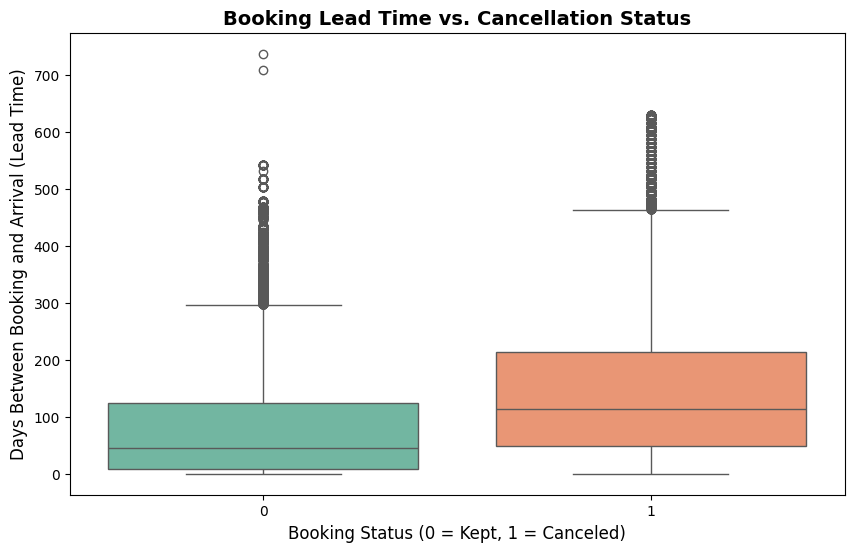

In [7]:
# Discovery Angle 1: Time is is enemy of commitment
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.boxplot(x='is_canceled', y='lead_time', data=df, hue='is_canceled', palette='Set2', legend=False)

plt.title('Booking Lead Time vs. Cancellation Status', fontsize=14, fontweight='bold')
plt.xlabel('Booking Status (0 = Kept, 1 = Canceled)', fontsize=12)
plt.ylabel('Days Between Booking and Arrival (Lead Time)', fontsize=12)

plt.show()

**Finding 1:**

The further in advance a booking is made, the higher risk it has of being canceled. From this, hotels should expect that bookings made far in advance will not be as reliable as those made last minute. This should be shown by having a caoutious attitude of bookings in advance (expecting a portion to get canceled) an a higher expectation of relying on last minute bookings to follow through.



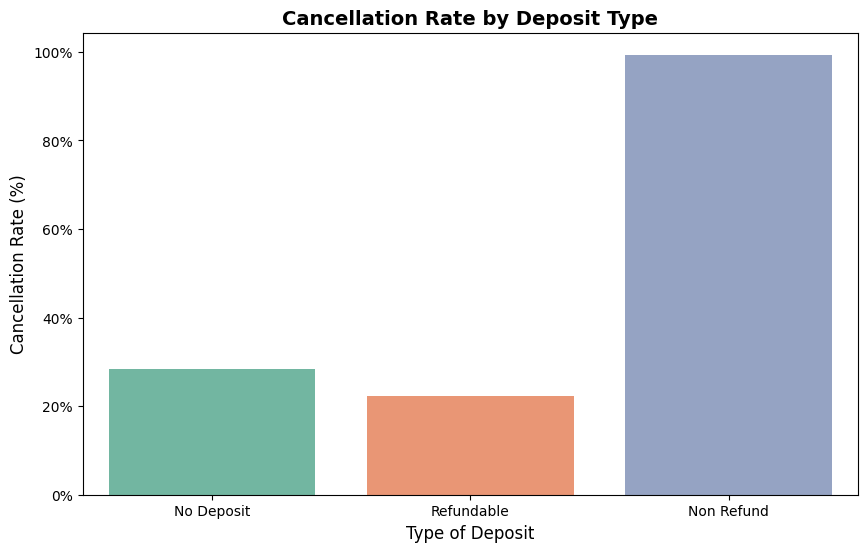

In [8]:
# Discovery Angle 2: Financial Skin in the Game.
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.barplot(
    x='deposit_type',
    y='is_canceled',
    data=df,
    hue='deposit_type',
    palette='Set2',
    legend=False,
    errorbar=None
)

plt.title('Cancellation Rate by Deposit Type', fontsize=14, fontweight='bold')
plt.xlabel('Type of Deposit', fontsize=12)
plt.ylabel('Cancellation Rate (%)', fontsize=12)

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

plt.show()

**Finding 2:**

The hotel must investigate which specific market segments are being offered these non-refundable rates. If third-party distributors are routinely locking up inventory with non-refundable deposits and then canceling, the hotel is likely turning away direct, paying customers in the meantime. We should tighten the contracting terms with these specific distributors to require higher upfront payments or stricter cancellation windows.



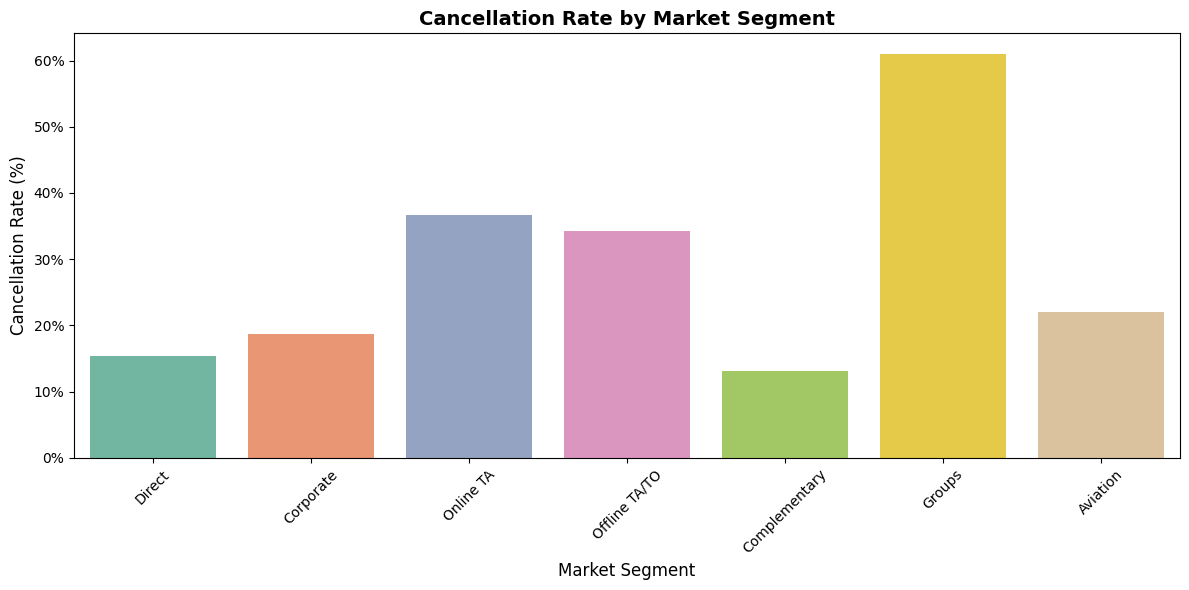

In [9]:
# Discovery Angle 3: Markets responsible for highest amount of cancellations
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

sns.barplot(
    x='market_segment',
    y='is_canceled',
    data=df,
    hue='market_segment',
    palette='Set2',
    legend=False,
    errorbar=None
)

plt.title('Cancellation Rate by Market Segment', fontsize=14, fontweight='bold')
plt.xlabel('Market Segment', fontsize=12)
plt.ylabel('Cancellation Rate (%)', fontsize=12)

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
plt.xticks(rotation=45)
plt.tight_layout() # Ensures the rotated labels don't get cut off

plt.show()

**Finding 3:**

The above chart fills in the gap on our finding from the previous chart, outling cancellations rates by market type, and confirmed our hypthosis of why non refundable reservations are not being upheld. The large 60% "groups" category confirms what we predicted: the third party tour operators are reserving blocks and cancelling last minute, accounting for a large amount of the non refundable cancellations. This results in a dangerous inventory displacement for the hotel. Moving forward, leadership must fundamentally restructure group contracting to enforce strict "attrition clauses" (financial penalties for dropping blocks of rooms late in the game) and cap the percentage of inventory allocated to Groups during peak seasons.



In [ ]:
# Additional explorations (optional — add as many cells as you need)


---

## Part 3: The Model (30 points)

Now build a model that predicts the outcome. Follow the scikit-learn workflow we learned in class.

### 3A. Prepare the data

- Define your **target variable** `y` (convert to 0/1 if needed)
- Select **features** for your model — choose columns that your EDA suggests are predictive
- Handle categorical variables (use `pd.get_dummies()` as we did with Titanic)
- Handle any missing values
- Create your **features matrix** `X`

**Write 2-3 sentences explaining *why* you chose these features.** Connect your feature selection to what you learned in Part 2.

In [11]:
# Data preparation
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
y = df['is_canceled']

features = ['lead_time', 'deposit_type', 'market_segment']
X_raw = df[features]

X_raw = X_raw.dropna()
y = y[X_raw.index]
X = pd.get_dummies(X_raw, columns=['deposit_type', 'market_segment'], drop_first=True)

print(X.head())

   lead_time  deposit_type_Non Refund  deposit_type_Refundable  \
0        342                    False                    False   
1        737                    False                    False   
2          7                    False                    False   
3         13                    False                    False   
4         14                    False                    False   

   market_segment_Complementary  market_segment_Corporate  \
0                         False                     False   
1                         False                     False   
2                         False                     False   
3                         False                      True   
4                         False                     False   

   market_segment_Direct  market_segment_Groups  market_segment_Offline TA/TO  \
0                   True                  False                         False   
1                   True                  False                         Fa

**Why these features?**

I chose lead time, deposit type, and market segment as the core features for this model because our data showed they are the primary drivers of cancellation. Specifically, we identified that extended lead times and the 'Groups' market segment carry failure rates of over 60%, and that 'Non Refundable' deposits act as a strong componant for these high-risk group bookings. By restricting the feature matrix to these proven variables, we ensure the model learns to identify the exact structural booking behaviors that are currently displacing hotel inventory, rather than getting distracted by noise



### 3B. Train/test split and model building

- Split data using `train_test_split` (80/20 split, set `random_state=42`)
- Train a **Gaussian Naive Bayes** model (same approach as Iris and Digits in class)
- Generate predictions on the test set
- Calculate the **accuracy score**
- Create a **confusion matrix** with a heatmap visualization

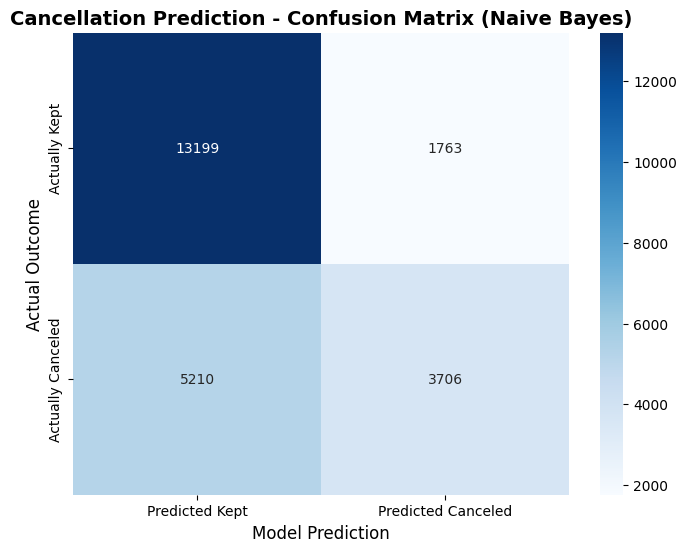

Overall Accuracy: 70.8%


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Your model code here

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

X = X.astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = GaussianNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Kept', 'Predicted Canceled'],
            yticklabels=['Actually Kept', 'Actually Canceled'])
plt.title('Cancellation Prediction - Confusion Matrix (Naive Bayes)', fontsize=14, fontweight='bold')
plt.ylabel('Actual Outcome', fontsize=12)
plt.xlabel('Model Prediction', fontsize=12)
plt.show()

print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.1%}")

### 3C. Interpret the results — in business terms

This is the part most analysts get wrong. Don't just report a number — **translate it into business impact.**

Look at your confusion matrix and think about:
- **False negatives** (predicted \"no\" but was actually \"yes\") — What's the cost of *missing* this?
- **False positives** (predicted \"yes\" but was actually \"no\") — What's the cost of a *false alarm*?
- Which type of error is worse for your client's business?

Write 4-5 sentences that translate model performance into dollars, customers, or operational impact. For example:

> *"Our model correctly identifies 78% of outcomes overall. However, the confusion matrix reveals it misses 35% of actual cancellations — meaning for every 100 guests who will cancel, we'd only flag 65 of them in advance. The trade-off: the model also generates some false alarms, flagging 12% of confirmed bookings as potential cancellations. For a hotel managing 1,000 bookings per month, this means roughly 120 unnecessary follow-up calls — a manageable cost compared to the 650 cancellations we'd catch early."*

**Model Performance — Business Translation:**

Our Naive Bayes model achieves an overall accuracy of roughly 71%, but the confusion matrix shows the true operational trade-offs of these predictions. The model produces 5,210 false negatives, meaning thousands of actual cancellations will slip through undetected, resulting in "spoiled" (empty) inventory and lost revenue. Conversely, the model generates 1,763 false positives, incorrectly flagging reliable guests as flight risks. For a hotel, this false alarm is arguably the more dangerous error; if revenue managers trust the model and aggressively resell those 1,763 rooms, they risk overbooking and having to "walk" confirmed guests to another property, which incurs immediate financial penalties and severely damages brand reputation. Ultimately, however, the model successfully identifies 3,706 true cancellations in advance, giving the commercial team a highly targeted list of risky bookings to proactively manage, potentially recovering thousands of dollars in revenue that would have otherwise been lost.


### 3D. (Bonus) Try a second model

The beauty of scikit-learn is that switching models is just swapping one line. Try one additional model and compare:

```python
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
```

Use the same train/test split. Compare accuracy and confusion matrices. Did the second model do better? Why might that be?

In [ ]:
# Optional: second model comparison


---

## Part 4: The Recommendation (10 points)

Your client is sitting across the table. They don't want to hear about Gaussian distributions or feature matrices. They want to know: **What should we do?**

Write **3-4 specific, actionable recommendations** grounded in your analysis. Each should:

1. **State the action** — What specifically should the company do?
2. **Cite the evidence** — What did your data show that supports this?
3. **Estimate the impact** — Even a rough estimate shows business thinking

| Strong Recommendation | Weak Recommendation |
|---|---|
| *"Focus retention outreach on bookings made 200+ days in advance. Our data shows these have a 60% cancellation rate vs. 20% for short-lead bookings. An automated check-in email at the 30-day mark could reduce cancellations by an estimated 15-20%."* | *"The company should look at lead time because it's important."* |

**Recommendations for Hotel:**

**1.** Overhaul Contracting for the "Groups" Segment. Implement strict, tiered "attrition clauses" (financial penalties) and rolling non-refundable deposit milestones for all wholesale and event group contracts.ur discovery phase proved that the "Groups" segment is the primary driver of inventory displacement, carrying a massive 60%+ cancellation rate. Furthermore, the data showed that blocks categorized under "Non Refundable" deposits are effectively failing at a near-100% rate. By forcing third-party organizers to pay heavy penalties for dropping blocks of rooms late in the game, the hotel will immediately reduce inventory spoilage, potentially recovering tens of thousands of dollars per quarter in rooms that can be resold to reliable retail guests.


**2.** Shift Marketing Spend to Direct and Corporate Channels. Cap the total percentage of hotel inventory allocated to wholesale/group channels during peak seasons and redirect marketing budget to heavily incentivize "Direct" and "Corporate" bookings. Our market segment analysis clearly demonstrated that Direct and Corporate bookings are incredibly stable, boasting cancellation rates safely under 20%. Shifting our overall channel mix by even 10-15% toward these reliable segments will drastically stabilize revenue forecasting, increase the average daily rate (ADR), and reduce the operational chaos caused by last-minute group drops.


**3.** Revise the Overbooking Strategy Based on Lead Time. Yield managers should confidently overbook the hotel for reservations made more than 3-4 months in advance, but rapidly tighten inventory controls once the 45-day window hits.The data clearly shows that time is the enemy of commitment; the median lead time for a canceled booking is over 100 days, compared to roughly 45 days for a fulfilled stay. Optimizing the overbooking curve based on lead time maximizes occupancy when the risk of cancellation is highest, while safely protecting the hotel from the severe financial penalties and reputation damage of having to "walk" a confirmed guest at the last minute.




---

## Part 5: The GitHub Portfolio (20 points)

Now package everything as a **professional portfolio piece** on GitHub.

### What to Submit

A **public GitHub repository** containing:

1. **This completed notebook** (`.ipynb`) — all code executed, all text cells filled in
2. **A README.md** — the star of the show (use the starter template below)
3. **At least one chart** saved as an image and embedded in the README

### The README: Your 60-Second Pitch

A hiring manager finds your GitHub. They'll spend **60 seconds** deciding if you're worth interviewing. Your README should follow the storytelling arc:

| Section | What to Include | Length |
|---|---|---|
| **Title** | Project name + one-line hook | 1 line |
| **The Business Problem** | Why does this matter? What's at stake? | 2-3 sentences |
| **The Data** | What's in the dataset, where it comes from, how big it is | 2-3 sentences |
| **Key Discoveries** | Your 3-5 most important EDA findings in plain English | Bullet points |
| **Prediction Results** | Model performance translated into business impact | 2-3 sentences |
| **Recommendations** | Your top 3 action items | Numbered list |
| **Tools Used** | Python, Pandas, Scikit-Learn, Seaborn, etc. | 1 line |

### README Quality Checklist

Before you submit, verify:

- [ ] Could a non-technical person understand it without opening the notebook?
- [ ] Does it lead with the business problem, not the technical approach?
- [ ] Are findings stated as insights, not descriptions of charts?
- [ ] Does it include at least one embedded visualization?
- [ ] Is the repo name professional? (e.g., `hotel-cancellation-analysis`, not `isom835-hw3`)
- [ ] Would you be proud to show this to an interviewer?

### README Starter Template

Copy the raw Markdown below into your GitHub repo's README.md file. Then **replace every bracketed placeholder** with your own content. The comments (inside `<!-- -->` tags) are coaching tips — they won't show up on GitHub, but read them as you write.

**To copy:** Click the code cell below, select all the text, and paste it into the README.md editor on GitHub.

In [15]:
# Run this cell to display the README template — then copy the printed output

readme_template = '''
# How hotel can begin to trust reservations again.

**One-line hook:** Start counting on your guests to follow through, as long as it the real guest making the reservation

---

## The Business Problem

A hotel chain in Portugal is struggling to understand why they have so many cancellations. Even with long term
and non refundable booking they are still seeing many last minute cancellations. This is results in the hotel losing millions
due to the lost opportunity to book reliable guests.


## The Data

We are working with a comprehensive dataset of 119,390 hotel booking records across 32 distinct features. Our baseline cancellation
rate is 37%, giving us a solid, moderately balanced target for our predictive model. Overall data quality is high, though we need to
address significant missing data in the 'company' and 'agent' fields (missing 94% and 13% of records, respectively) and investigate
a few potential outliers in room rates and party sizes before proceeding.

<!--
Tip: Translate technical details into human terms.
Instead of "The dataset has 32 features and 119,390 rows..."
Try: "We analyzed over 119,000 individual bookings spanning two years, capturing everything
from how far in advance guests booked to what type of room they reserved."
-->

## Key Discoveries

- ** Time is is enemy of commitment :** [The further in advance a booking is made, the higher risk it has of being canceled. From this,
hotels should expect that bookings made far in advance will not be as reliable as those made last minute. This should be shown by having
a caoutious attitude of bookings in advance (expecting a portion to get canceled) an a higher expectation of relying on last minute
bookings to follow through.
- **Financial Skin in the Game:** The hotel must investigate which specific market segments are being offered these non-refundable rates.
If third-party distributors are routinely locking up inventory with non-refundable deposits and then canceling, the hotel is likely
turning away direct, paying customers in the meantime. We should tighten the contracting terms with these specific distributors to require
higher upfront payments or stricter cancellation windows.
- **Markets responsible for highest amount of cancellations:** The above chart fills in the gap on our finding from the previous chart,
outling cancellations rates by market type, and confirmed our hypthosis of why non refundable reservations are not being upheld. The large
60% "groups" category confirms what we predicted: the third party tour operators are reserving blocks and cancelling last minute,
accounting for a large amount of the non refundable cancellations. This results in a dangerous inventory displacement for the hotel. Moving
forward, leadership must fundamentally restructure group contracting to enforce strict "attrition clauses" (financial penalties for
dropping blocks of rooms late in the game) and cap the percentage of inventory allocated to Groups during peak seasons.

<!--
Tip: Write findings as "headlines" a newspaper editor would approve.
Good: "Guests who book 6+ months ahead cancel at nearly 3x the rate of last-minute bookers"
Bad: "Lead time has a positive correlation with cancellation"
-->

## Visualizing the Story

<!-- Embed your most compelling chart. Pick the ONE visual that best captures your main finding. -->

!With the data anomalies removed, the true baseline of our customer behavior is exposed. The "Groups" segment emerges as the undisputed
highest-risk channel, canceling over 60% of the time. Travel Agents (both Online and Offline) also show significant volatility, canceling
roughly 35% of their bookings. In stark contrast, "Direct" bookings and "Corporate" accounts are highly reliable, with cancellation rates
sitting safely under 20%.(Cancellation_by_Market.png)

*By allowing high-risk "Groups" to hold our rooms hostage during peak booking windows, we are actively turning away the reliable "Direct"
retail customers who actually show up and pay.*

## Prediction Model

Our Naive Bayes model achieves an overall accuracy of roughly 71%, but the confusion matrix shows the true operational trade-offs of these
predictions. The model produces 5,210 false negatives, meaning thousands of actual cancellations will slip through undetected, resulting in
"spoiled" (empty) inventory and lost revenue. Conversely, the model generates 1,763 false positives, incorrectly flagging reliable guests
as flight risks. For a hotel, this false alarm is arguably the more dangerous error; if revenue managers trust the model and aggressively
resell those 1,763 rooms, they risk overbooking and having to "walk" confirmed guests to another property, which incurs immediate financial
penalties and severely damages brand reputation. Ultimately, however, the model successfully identifies 3,706 true cancellations in
advance, giving the commercial team a highly targeted list of risky bookings to proactively manage, potentially recovering thousands of
dollars in revenue that would have otherwise been lost.

<!--
Tip: Translate model metrics into business impact.
Instead of "The model achieved 78% accuracy..."
Try: "Our model correctly flags 8 out of 10 at-risk bookings, giving the hotel front desk team
enough lead time to proactively reach out and offer flexible rebooking options."
-->

## Recommendations

1. **[Overhaul Contracting for the "Groups" Segment. :** Implement strict, tiered "attrition clauses" (financial penalties) and rolling
non-refundable deposit milestones for all wholesale and event group contracts.ur discovery phase proved that the "Groups" segment is the
primary driver of inventory displacement, carrying a massive 60%+ cancellation rate. Furthermore, the data showed that blocks categorized
under "Non Refundable" deposits are effectively failing at a near-100% rate. By forcing third-party organizers to pay heavy penalties for
dropping blocks of rooms late in the game, the hotel will immediately reduce inventory spoilage, potentially recovering tens of thousands
of dollars per quarter in rooms that can be resold to reliable retail guests.
2. **Shift Marketing Spend to Direct and Corporate Channels.:** Cap the total percentage of hotel inventory allocated to wholesale/group
channels during peak seasons and redirect marketing budget to heavily incentivize "Direct" and "Corporate" bookings. Our market segment
analysis clearly demonstrated that Direct and Corporate bookings are incredibly stable, boasting cancellation rates safely under 20%.
Shifting our overall channel mix by even 10-15% toward these reliable segments will drastically stabilize revenue forecasting, increase
the average daily rate (ADR), and reduce the operational chaos caused by last-minute group drops.
3. **Revise the Overbooking Strategy Based on Lead Time:** Yield managers should confidently overbook the hotel for reservations made
more than 3-4 months in advance, but rapidly tighten inventory controls once the 45-day window hits.The data clearly shows that time
is the enemy of commitment; the median lead time for a canceled booking is over 100 days, compared to roughly 45 days for a fulfilled
stay. Optimizing the overbooking curve based on lead time maximizes occupancy when the risk of cancellation is highest, while safely
protecting the hotel from the severe financial penalties and reputation damage of having to "walk" a confirmed guest at the last minute.

## Tools & Techniques

Python | Pandas | Scikit-Learn | Matplotlib | Seaborn | Gaussian Naive Bayes | Google Colab

---

*This project was completed as part of ISOM 835: Predictive Analytics at Suffolk University\'s
Sawyer Business School.*
'''

print(readme_template)


# How hotel can begin to trust reservations again.

**One-line hook:** Start counting on your guests to follow through, as long as it the real guest making the reservation

---

## The Business Problem

A hotel chain in Portugal is struggling to understand why they have so many cancellations. Even with long term 
and non refundable booking they are still seeing many last minute cancellations. This is results in the hotel losing millions 
due to the lost opportunity to book reliable guests.


## The Data

We are working with a comprehensive dataset of 119,390 hotel booking records across 32 distinct features. Our baseline cancellation 
rate is 37%, giving us a solid, moderately balanced target for our predictive model. Overall data quality is high, though we need to 
address significant missing data in the 'company' and 'agent' fields (missing 94% and 13% of records, respectively) and investigate 
a few potential outliers in room rates and party sizes before proceeding.

<!--
Tip: Tran

### Quick GitHub Guide

If you're new to GitHub:

1. Create a free account at [github.com](https://github.com)
2. Click **\"+\"** (top right) then **New repository**
3. Give it a professional name (e.g., `hotel-cancellation-analysis`)
4. Check **\"Add a README file\"** then click **Create repository**
5. Click **\"Add file\"** then **\"Upload files\"** to add your notebook
6. Click **README.md** then the pencil icon to edit directly in the browser

**To embed a chart in your README:**
1. In your notebook, save a chart: `plt.savefig('my_chart.png', bbox_inches='tight', dpi=150)`
2. Download the `.png` and upload it to your repo
3. In README.md, add: `![Description of chart](my_chart.png)`

### How to Submit

Submit the **link to your public GitHub repository** on Canvas.

---

## Grading Rubric

| Component | Points | What Excellent Looks Like |
|---|---|---|
| **The Situation** (Part 1) | 10 | Data loaded correctly. Summary is accurate and written for a non-technical audience. Target distribution is clearly stated in business terms. |
| **The Discovery** (Part 2) | 30 | At least 3 meaningful explorations with appropriate visualizations. Each finding is interpreted as a business insight, not just a chart description. Findings build on each other to tell a coherent story. |
| **The Model** (Part 3) | 30 | Scikit-learn workflow executed correctly. Feature selection is justified by EDA findings. Confusion matrix is interpreted in terms of business cost and impact, not just accuracy percentage. |
| **The Recommendation** (Part 4) | 10 | 3+ specific, actionable recommendations. Each is grounded in evidence from the analysis. Demonstrates business thinking, not just technical reporting. |
| **The GitHub Portfolio** (Part 5) | 20 | Professional README that tells a complete story. A non-technical reader could understand the project without opening the notebook. Includes embedded visual. Repo is cleanly organized with a professional name. |
| **Total** | **100** | |


### Credentialing Competencies

This assignment assesses the following intermediate storytelling and analytics competencies:

| Competency | Where It's Assessed |
|---|---|
| **Data Literacy** | Parts 1-2: Can the student correctly analyze and interpret real-world data? |
| **Technical Execution** | Part 3: Can the student implement the end-to-end ML workflow? |
| **Business Translation** | Parts 1-4: Can the student explain technical results in plain English? |
| **Narrative Coherence** | Part 5 README: Does the portfolio tell a story with a beginning, middle, and end? |
| **Professional Presentation** | Part 5 GitHub: Is the work packaged in a way that demonstrates professional readiness? |

---

*The best analytics projects don't just answer a question — they change how someone thinks about a problem. Make yours count.*